In [1]:
from google.colab import drive

# 1 Monte Google Drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
import os
import glob
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# 2 Chemin du dossier extrait sur Google Drive
dossier_path = '/content/drive/MyDrive/Nouveau/Lung250M_4B/Lung250M_4B'

# 3 Lister les fichiers dans le dossier
fichiers = os.listdir(dossier_path)
print("Fichiers dans le dossier :", fichiers)

%matplotlib inline

# 3. Lister les fichiers images et masques
images_train = sorted(glob.glob(os.path.join(dossier_path, "imagesTr", "*.nii.gz")))
labels_train = sorted(glob.glob(os.path.join(dossier_path, "masksTr", "*.nii.gz")))

# Lister les fichiers de test (imagesTs et masksTs)
images_test = sorted(glob.glob(os.path.join(dossier_path, "imagesTs", "*.nii.gz")))
labels_test = sorted(glob.glob(os.path.join(dossier_path, "masksTs", "*.nii.gz")))

# 4. Afficher le nombre d'images et de masques
print('Nombre d\'images :', len(images_train), 'Nombre de masques :', len(labels_train))

Fichiers dans le dossier : ['imagesTs', 'imagesTr', 'masksTs', 'masksTr']
Nombre d'images : 42 Nombre de masques : 42


img shape: (332, 218, 267)  lbl shape: (332, 218, 267)
img intensity min.: -1024.0  max.: 1599.203125  unique labels: [0. 1.]


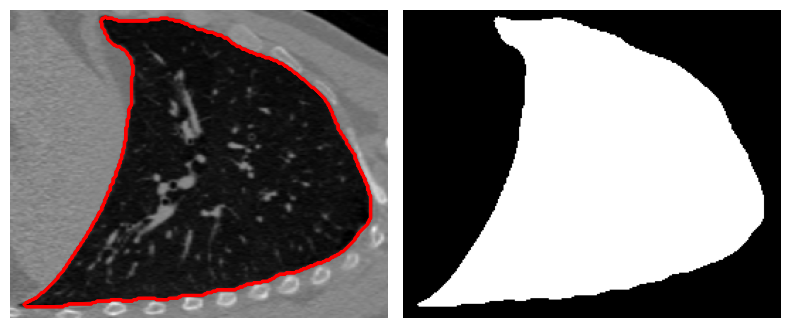

In [3]:
# 5 Chargement d'une image et du masque
img = nib.load(images_train[0]).get_fdata()
lbl = nib.load(labels_train[0]).get_fdata()
# Affichage des dimensions du volume
print('img shape:', img.shape, ' lbl shape:', lbl.shape)

print('img intensity min.:', np.min(img), ' max.:', np.max(img), ' unique labels:', np.unique(lbl)) # pour vérifier le nombre de classe du masque

# Visualisation de la coupe 100
slice_idx = 100

plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.imshow(img[slice_idx], cmap='gray', vmin=-1000, vmax=1000) # affiche le slice en niveau de gris
plt.contour(lbl[slice_idx], colors='red') # Pour le contour en rouge
plt.axis('off')
# Pour afficher uniquement le masque
plt.subplot(1,2,2)
plt.imshow(lbl[slice_idx], cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:

!pip install --force-reinstall numpy monai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/

In [4]:
from monai.utils import first, set_determinism

set_determinism(seed=0) # Pour fixer la seed dés le départ

In [5]:
# 1. Créer une liste de dictionnaires pour les paires image-masque d'entraînement
train_data_dicts = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(images_train, labels_train)
]

# 2. Diviser les données d'entraînement en train/val (par exemple 85%/15%)
train_split = int(0.84 * len(train_data_dicts))
train_files = train_data_dicts[:train_split]
val_files = train_data_dicts[train_split:]

# 3. Créer une liste de dictionnaires pour les données de test
test_files = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(images_test, labels_test)
]

# 4. Afficher le nombre de fichiers dans chaque ensemble
print(f"Entraînement : {len(train_files)} fichiers")
print(f"Validation : {len(val_files)} fichiers")
print(f"Test : {len(test_files)} fichiers")


Entraînement : 35 fichiers
Validation : 7 fichiers
Test : 30 fichiers


In [6]:
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandAffined,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
)
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch

# Transformations
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    #ScaleIntensityRanged(keys=["label"], a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Orientationd(keys=["image", "label"], axcodes="PLS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    RandSpatialCropd(keys=["image", "label"], roi_size=[96, 96, 96], random_size=False),
    RandAffined(keys=["image", "label"], mode=('bilinear', 'nearest'), prob=1.0, spatial_size=(96, 96, 96), rotate_range=(0, 0, np.pi/15), scale_range=(0.1, 0.1, 0.1)),
    RandFlipd(keys=["image", "label"], prob=0.25, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.25, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.25, spatial_axis=2),
    RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    #ScaleIntensityRanged(keys=["label"], a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Orientationd(keys=["image", "label"], axcodes="PLS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
])

test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    #ScaleIntensityRanged(keys=["label"], a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Orientationd(keys=["image", "label"], axcodes="PLS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
])


/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


img shape: torch.Size([96, 96, 96]), lbl shape: torch.Size([96, 96, 96])


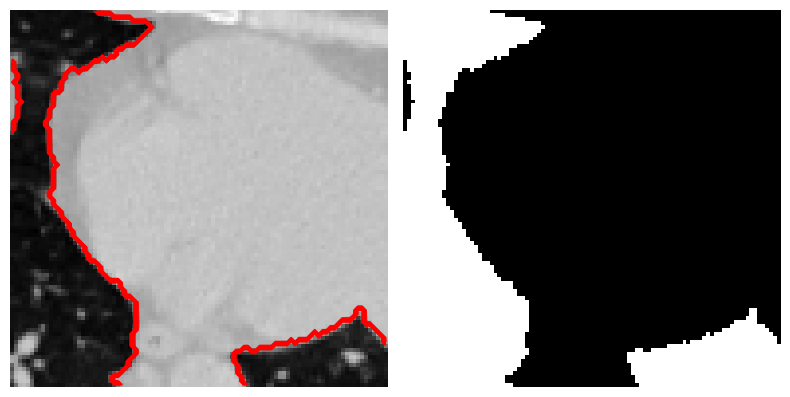

In [7]:
# Visualisation de l'image après les transformation
sample_ds = Dataset(data=train_files, transform=train_transforms)
sample_dataloader = DataLoader(sample_ds, batch_size=1)
sample_batch = first(sample_dataloader)

img, lbl = sample_batch["image"][0][0], sample_batch["label"][0][0]
print(f"img shape: {img.shape}, lbl shape: {lbl.shape}")

slice_idx = 64
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.imshow(img[:,:,slice_idx], cmap='gray')
plt.contour(lbl[:,:,slice_idx], colors='red')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(lbl[:,:,slice_idx], cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

Maintenant, nous créons des dataloaders pour les jeux de données d'entraînement et de validation en utilisant la bibliothèque MONAI. La classe `CacheDataset` est utilisée pour créer les jeux de données d'entraînement et de validation en spécifiant les chemins des fichiers, les transformations de prétraitement, le taux de cache et le nombre de travailleurs pour le traitement parallèle. C'est une classe de la bibliothèque MONAI qui permet de créer un jeu de données à partir d'une liste de fichiers de données et d'une fonction de transformation. Elle peut être utilisée pour mettre en cache les données prétraitées en mémoire afin d'y accéder plus rapidement pendant l'entraînement, ce qui peut être particulièrement utile pour de grands jeux de données.

In [8]:
# Créer les datasets avec CacheDataset
train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0)
val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1.0)
test_ds = CacheDataset(data=test_files, transform=test_transforms, cache_rate=1.0)

# Créer les DataLoaders
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1)
test_loader = DataLoader(test_ds, batch_size=1)


Loading dataset: 100%|██████████| 30/30 [02:58<00:00,  5.95s/it]


In [9]:
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.networks.layers import Norm

device = torch.device("cuda:0")
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [10]:
from monai.inferers import sliding_window_inference

# Define hyperparameters
max_epochs = 400
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

# Define post-processing transforms
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=2)])
post_label = Compose([AsDiscrete(to_onehot=2)])

# Training loop
for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)

    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            val_sample = next(iter(val_loader))
            print("Label shape :", val_sample["label"].shape)
            print("Label unique values :", torch.unique(val_sample["label"]))
            print("Image shape :", val_sample["image"].shape)
            for val_data in val_loader:
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device),
                val_outputs = sliding_window_inference(val_inputs, (96, 96, 96), 1, model)

                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]

                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            metric = dice_metric.aggregate().item()

            # reset the status for next validation round
            dice_metric.reset()

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_metric_model.pth")
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
            )
from google.colab import files
files.download('best_metric_model.pth')


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
9/17, train_loss: 0.0180
10/17, train_loss: 0.0157
11/17, train_loss: 0.0139
12/17, train_loss: 0.0146
13/17, train_loss: 0.0162
14/17, train_loss: 0.0150
15/17, train_loss: 0.0133
16/17, train_loss: 0.0156
17/17, train_loss: 0.0173
18/17, train_loss: 0.0225
epoch 188 average loss: 0.0169
Label shape : torch.Size([1, 1, 157, 222, 141])
Label unique values : metatensor([0., 1.])
Image shape : torch.Size([1, 1, 157, 222, 141])
current epoch: 188 current mean dice: 0.9576
best mean dice: 0.9803 at epoch: 134
----------
epoch 189/400
1/17, train_loss: 0.0135
2/17, train_loss: 0.0172
3/17, train_loss: 0.0177
4/17, train_loss: 0.0155
5/17, train_loss: 0.0133
6/17, train_loss: 0.0170
7/17, train_loss: 0.0156
8/17, train_loss: 0.0153
9/17, train_loss: 0.0150
10/17, train_loss: 0.0136
11/17, train_loss: 0.0164
12/17, train_loss: 0.0144
13/17, train_loss: 0.0128
14/17, train_loss: 0.0143
15/17, train_loss: 0.0147
16/17

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
print(
    f"train completed, best_metric: {best_metric:.4f} "
    f"at epoch: {best_metric_epoch}")

train completed, best_metric: 0.9873 at epoch: 234


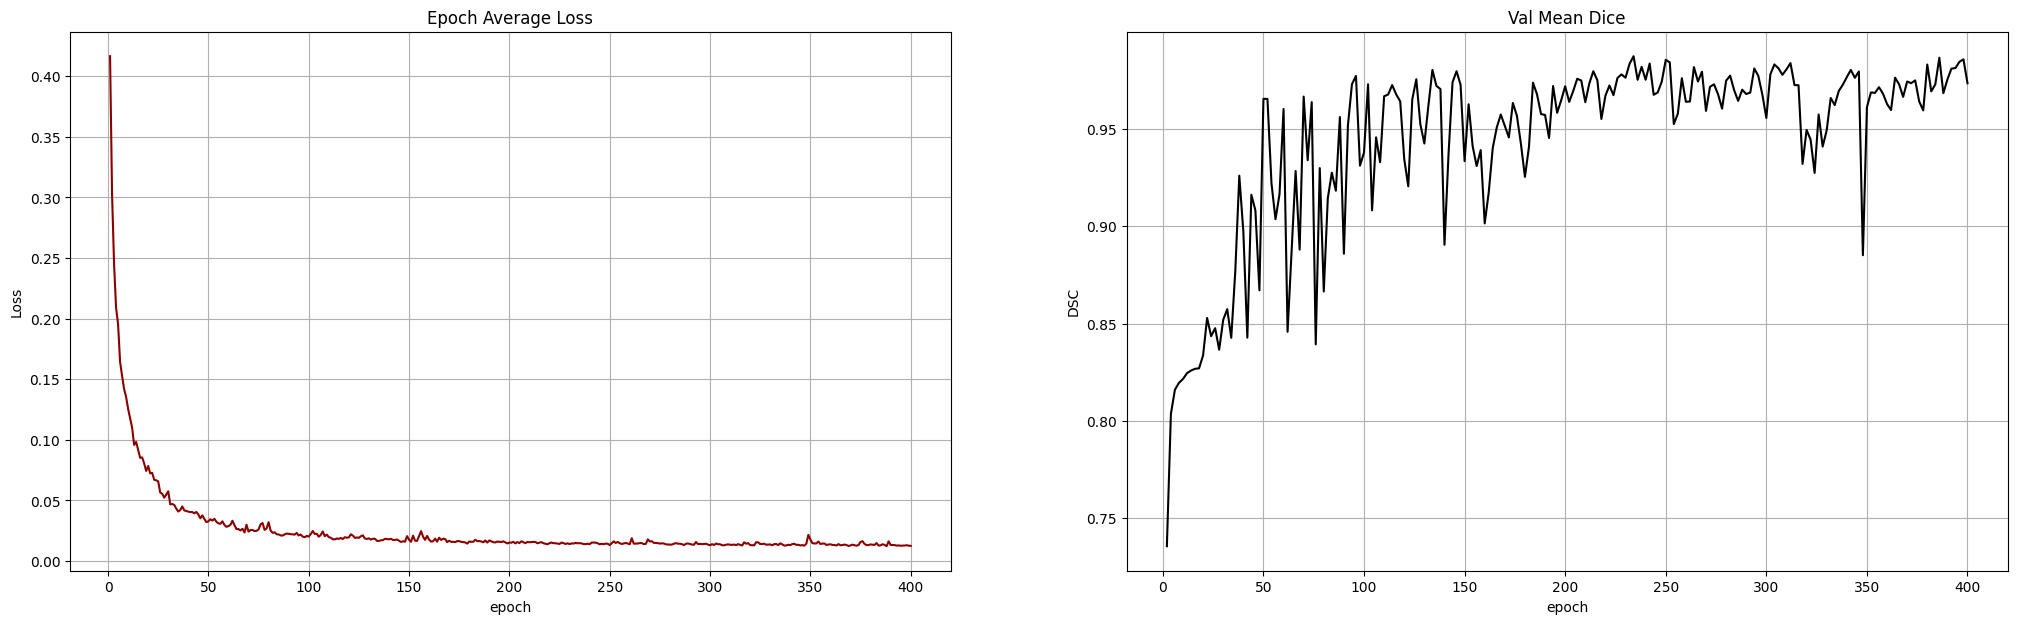

In [12]:
plt.figure("train", (25,7))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.ylabel("Loss")
plt.xlabel("epoch")
plt.plot(x, y, color='darkred')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.ylabel("DSC")
plt.xlabel("epoch")
plt.grid(True)
plt.plot(x, y, color='black')
plt.show()

**Make Predictions from Test Data**

In [13]:
test_ds = Dataset(data=test_files, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=1)

post_transforms = Compose([
    Invertd(
        keys="pred",
        transform=val_transforms,
        orig_keys="image",
        meta_keys="pred_meta_dict",
        orig_meta_keys="image_meta_dict",
        meta_key_postfix="meta_dict",
        nearest_interp=False,
        to_tensor=True,
    ),
    AsDiscreted(keys="pred", argmax=True, to_onehot=2),
    SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
])

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-05-02 19:41:43,662 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


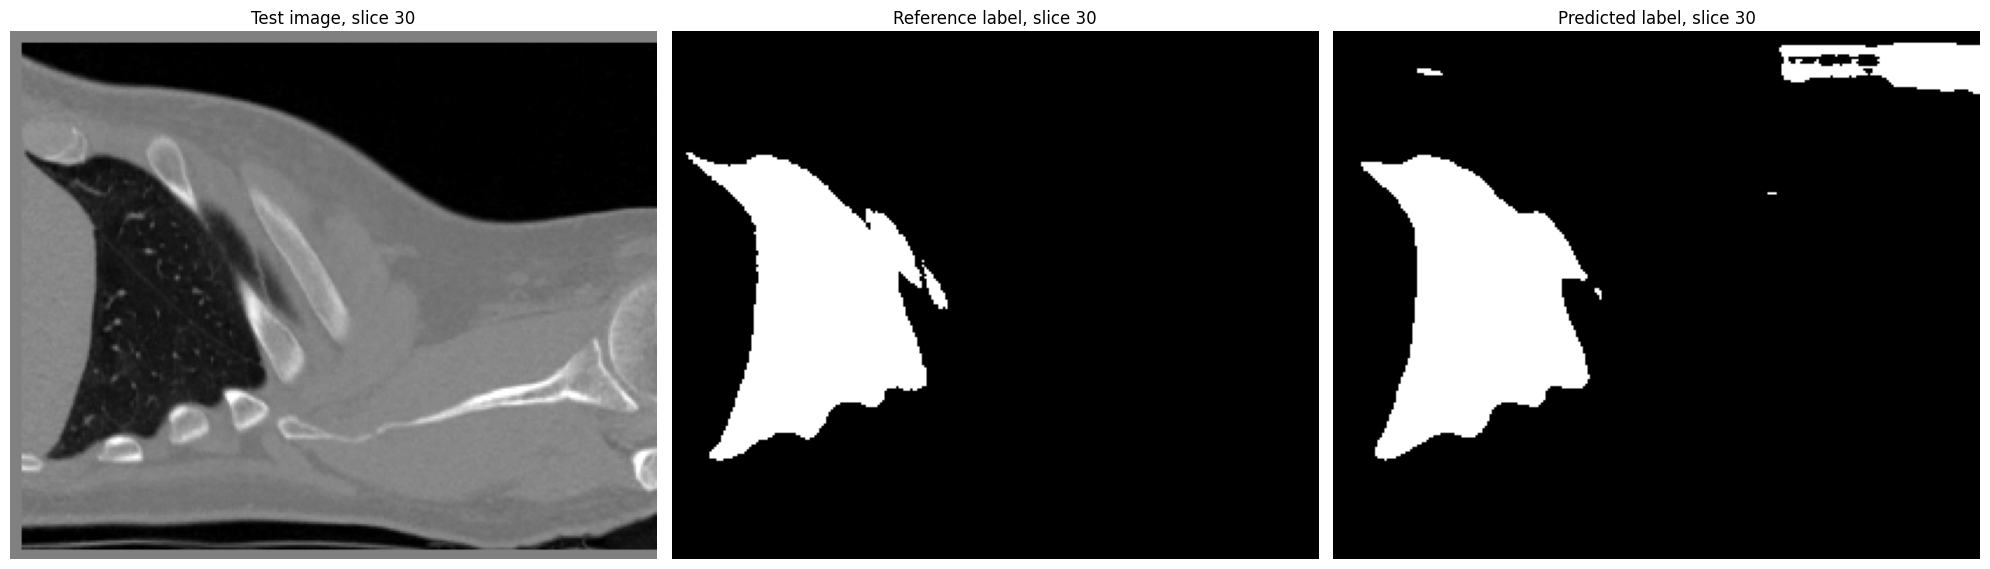

In [14]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 30
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-05-02 19:41:58,435 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


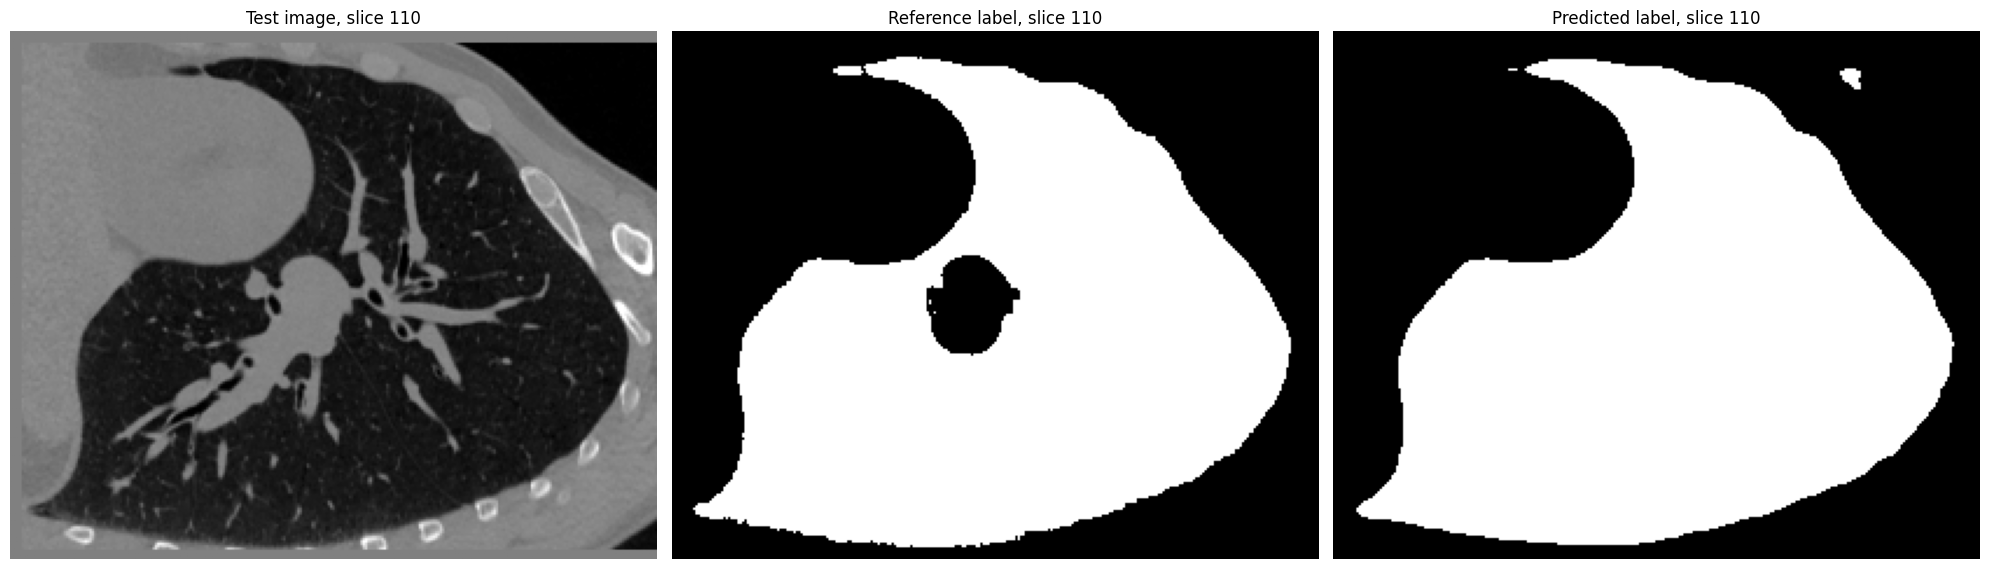

In [15]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 110
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-05-02 19:42:11,072 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


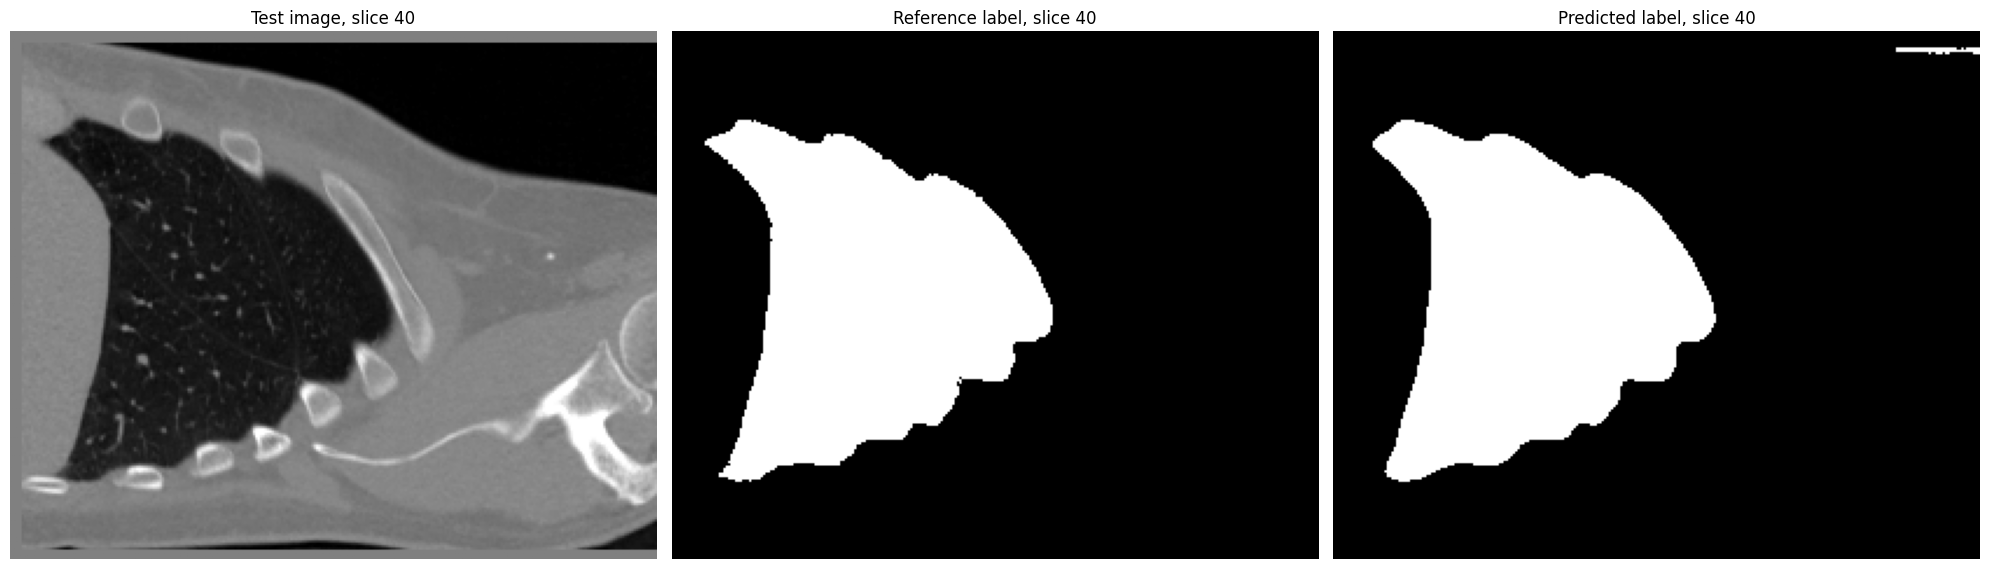

In [16]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 40
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-05-02 19:42:24,684 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


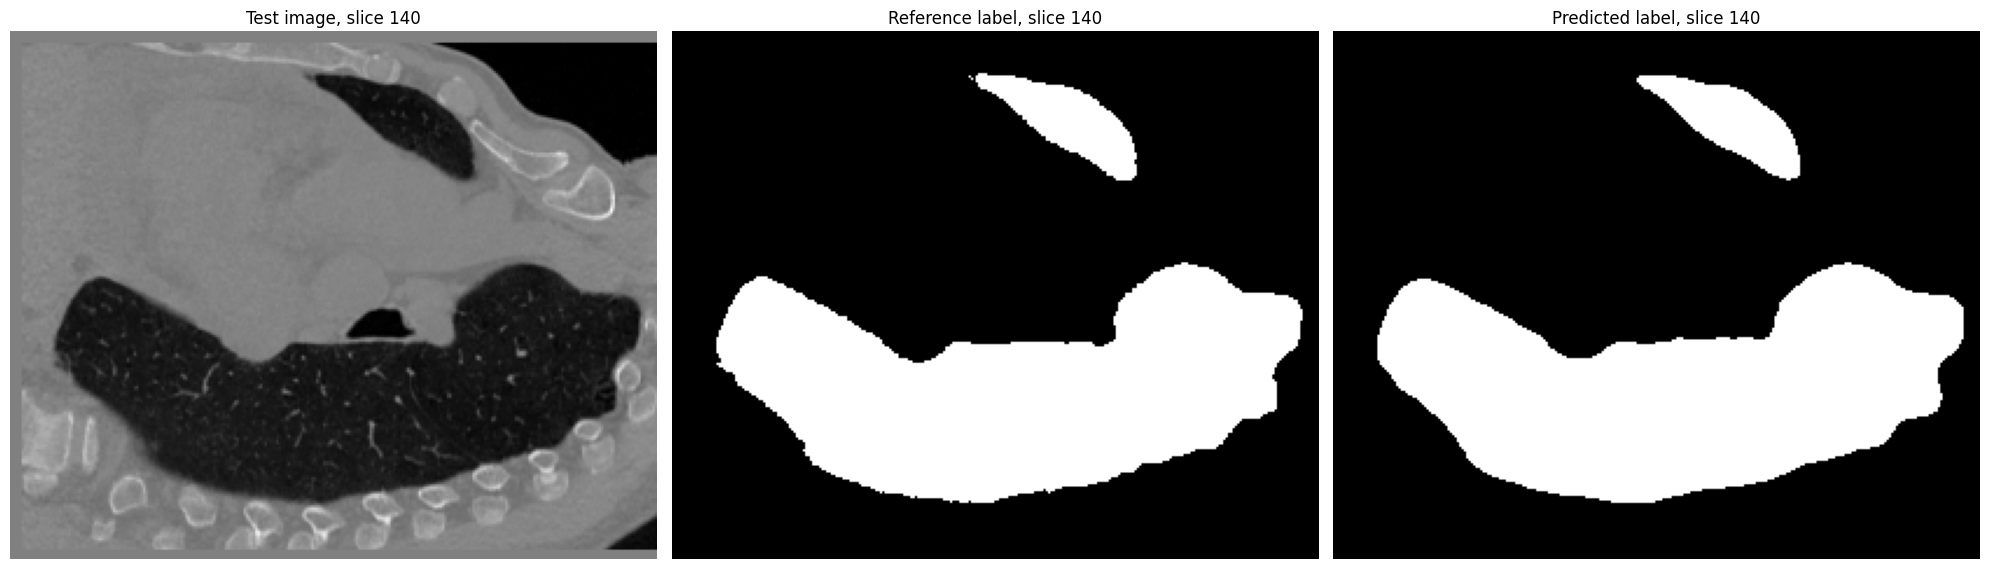

In [17]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 140
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Traitement de l'image de test n°1
Nombre de voxels dans le masque prédit: 1317479
Nombre de voxels dans le masque de référence: 1287201
Différence de voxels: 30278.0
TP: 1273043, FP: 44436, FN: 14158, TN: 2992097
Traitement de l'image de test n°2
Nombre de voxels dans le masque prédit: 728828
Nombre de voxels dans le masque de référence: 712978
Différence de voxels: 15850.0
TP: 705289, FP: 23539, FN: 7689, TN: 3587217
Traitement de l'image de test n°3
Nombre de voxels dans le masque prédit: 1312145.0
Nombre de voxels dans le masque de référence: 1308514
Différence de voxels: 3631.0
TP: 1287852, FP: 24293, FN: 20662, TN: 3396807
Traitement de l'image de test n°4
Nombre de voxels dans le masque prédit: 601385.0
Nombre de voxels dans le masque de référence: 589175
Différence de voxels: 12210.0
TP: 578286, FP: 23099, FN: 10889, TN: 4117340
Traitement de l'image de test n°5
Nombre de voxels dans le masque prédit: 1052486
Nombre de voxels dans le masque de référence: 1029678
Différence de vo

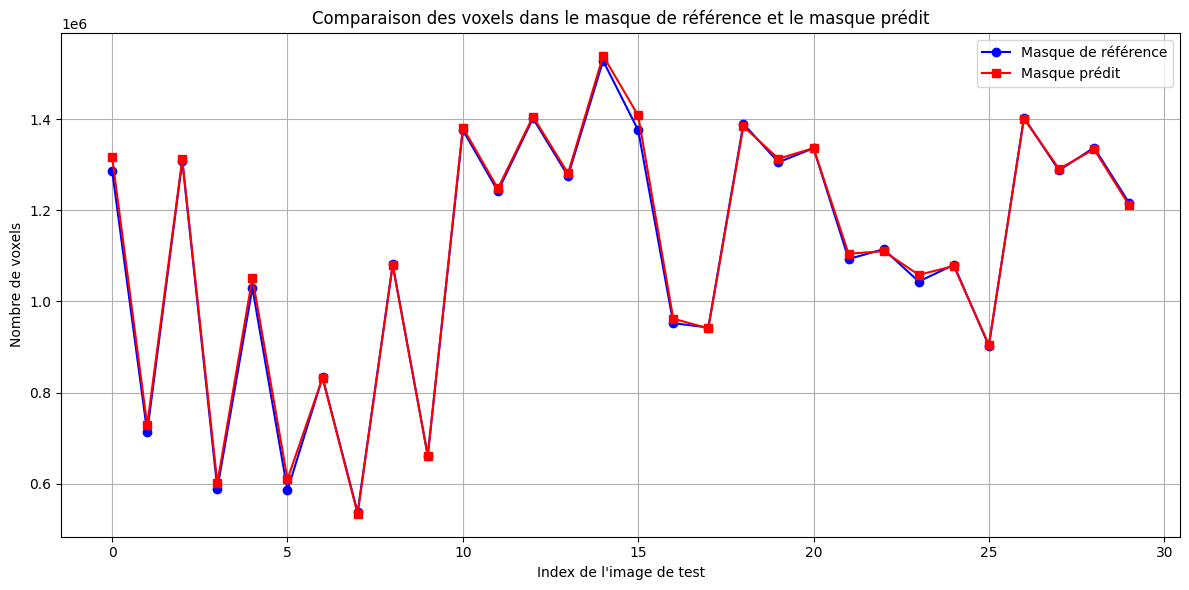

In [18]:
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

from monai.transforms import LoadImaged, AsDiscrete
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

model.load_state_dict(torch.load("best_metric_model.pth", map_location=device))

model.eval()  # Mettre le modèle en mode évaluation

# Transformations pour le post-traitement
post_pred = AsDiscrete(argmax=True, to_onehot=2)

# Listes pour stocker les résultats
reference_voxels = []
predicted_voxels = []
TP_list = []
FP_list = []
FN_list = []
TN_list = []

# Parcourir les données de test
for i, test_data in enumerate(test_loader):
    print(f"Traitement de l'image de test n°{i + 1}")
    test_inputs, test_labels = test_data["image"].to(device), test_data["label"].to(device)

    # Inférence avec sliding window
    with torch.no_grad():
        test_outputs = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)

    # Post-traitement des sorties
    test_outputs = [post_pred(i) for i in decollate_batch(test_outputs)]

    # Convertir les masques en numpy arrays et supprimer les dimensions supplémentaires
    predicted_mask = test_outputs[0][1].cpu().numpy()
    predicted_mask = np.squeeze(predicted_mask)  # Supprimer les dimensions supplémentaires
    reference_mask = (test_labels[0] == 1).cpu().numpy().astype(np.uint8)
    reference_mask = np.squeeze(reference_mask)  # Supprimer les dimensions supplémentaires

    # Redimensionner le masque prédit à la taille du masque de référence
    if predicted_mask.shape != reference_mask.shape:
        zoom_factors = np.array(reference_mask.shape) / np.array(predicted_mask.shape)
        predicted_mask = scipy.ndimage.zoom(predicted_mask, zoom_factors, order=0)
        predicted_mask = (predicted_mask > 0.5).astype(np.int32)  # Re-binariser après redimensionnement

    # Calculer le nombre de voxels
    num_voxels_predicted = np.sum(predicted_mask)
    num_voxels_reference = np.sum(reference_mask)

    reference_voxels.append(num_voxels_reference)
    predicted_voxels.append(num_voxels_predicted)

    # Calcul des métriques (après le redimensionnement)
    TP = np.logical_and(predicted_mask == 1, reference_mask == 1).sum()
    FP = np.logical_and(predicted_mask == 1, reference_mask == 0).sum()
    FN = np.logical_and(predicted_mask == 0, reference_mask == 1).sum()
    TN = np.logical_and(predicted_mask == 0, reference_mask == 0).sum()

    TP_list.append(TP)
    FP_list.append(FP)
    FN_list.append(FN)
    TN_list.append(TN)

    print(f"Nombre de voxels dans le masque prédit: {num_voxels_predicted}")
    print(f"Nombre de voxels dans le masque de référence: {num_voxels_reference}")
    print(f"Différence de voxels: {num_voxels_predicted - num_voxels_reference}")
    print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")

# Calcul des métriques globales
total_TP = np.sum(TP_list)
total_FP = np.sum(FP_list)
total_FN = np.sum(FN_list)
total_TN = np.sum(TN_list)

precision = total_TP / (total_TP + total_FP + 1e-8)
recall = total_TP / (total_TP + total_FN + 1e-8)

print("\n--- Résultats globaux ---")
print(f"Précision : {precision:.4f} | Rappel : {recall:.4f}")

# Affichage du graphe comparatif
plt.figure(figsize=(12, 6))
x = np.arange(len(test_files))

plt.plot(x, reference_voxels, label="Masque de référence", marker='o', color='blue')
plt.plot(x, predicted_voxels, label="Masque prédit", marker='s', color='red')

plt.xlabel("Index de l'image de test")
plt.ylabel("Nombre de voxels")
plt.title("Comparaison des voxels dans le masque de référence et le masque prédit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()